In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')





# 1. Load datasets

In [ ]:
application_train = pd.read_csv("application_train.csv")
application_test = pd.read_csv("application_test.csv")
previous_application = pd.read_csv("previous_application.csv")
bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")
pos = pd.read_csv("POS_CASH_balance.csv")
installments = pd.read_csv("installments_payments.csv")
cc = pd.read_csv("credit_card_balance.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'previous_application.csv'

# 2. EDA - Target Distribution

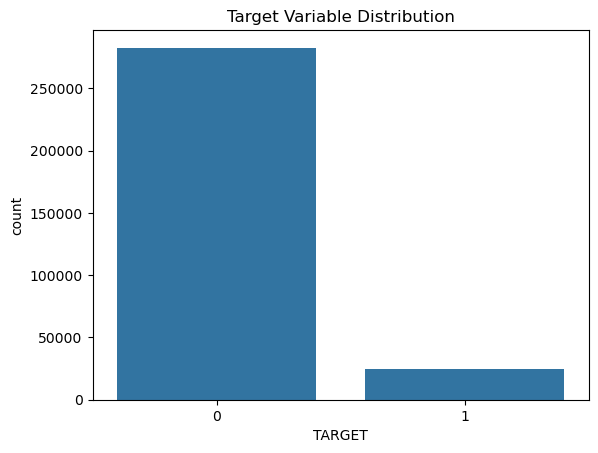

In [12]:
sns.countplot(x='TARGET', data=application_train)
plt.title('Target Variable Distribution')
plt.show()

hna hwa by predict customer msh hay2dar ysaded el qard target=1 , not target=0 3ala hasab customer info

 To understand what we are predicting, we look at the distribution of the target: 1 means default, 0 means no default.
 This helps us check class balance and see if our data is skewed.

# 3. Missing values visualization

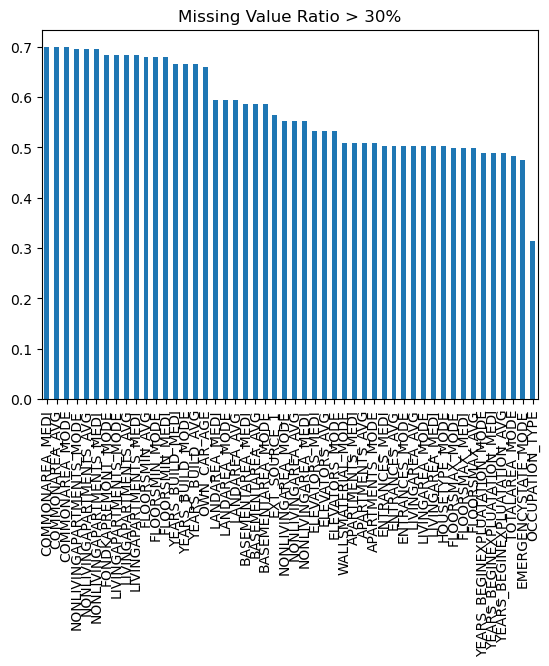

In [13]:
missing = application_train.isnull().mean().sort_values(ascending=False)
missing[missing > 0.3].plot(kind='bar', title='Missing Value Ratio > 30%')
plt.show()

The chart shows features with over 30% missing values, helping us decide which ones to drop or fill to improve model quality.

# 4. Aggregation function for feature engineering

In [14]:
def agg_numeric(df, group_var, prefix):
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df[group_var] = df[group_var]
    agg = numeric_df.groupby(group_var).agg(['count', 'mean', 'max', 'min', 'sum'])
    agg.columns = [prefix + '_'.join(col).strip() for col in agg.columns.values]
    return agg.reset_index()

define a function that takes any dataset and groups it by customer ID, calculating summary stats (mean, max, etc.).
 This is how we turn many rows of past data into a few useful numbers per customer.

# 5. Merge engineered features

In [15]:
bureau_balance_agg = agg_numeric(bureau_balance, 'SK_ID_BUREAU', 'bb')
bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')
bureau_agg = agg_numeric(bureau, 'SK_ID_CURR', 'bureau')
application_train = application_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
application_test = application_test.merge(bureau_agg, on='SK_ID_CURR', how='left')

prev_agg = agg_numeric(previous_application, 'SK_ID_CURR', 'prev')
application_train = application_train.merge(prev_agg, on='SK_ID_CURR', how='left')
application_test = application_test.merge(prev_agg, on='SK_ID_CURR', how='left')

pos_agg = agg_numeric(pos, 'SK_ID_CURR', 'pos')
application_train = application_train.merge(pos_agg, on='SK_ID_CURR', how='left')
application_test = application_test.merge(pos_agg, on='SK_ID_CURR', how='left')

installments_agg = agg_numeric(installments, 'SK_ID_CURR', 'inst')
application_train = application_train.merge(installments_agg, on='SK_ID_CURR', how='left')
application_test = application_test.merge(installments_agg, on='SK_ID_CURR', how='left')

cc_agg = agg_numeric(cc, 'SK_ID_CURR', 'cc')
application_train = application_train.merge(cc_agg, on='SK_ID_CURR', how='left')
application_test = application_test.merge(cc_agg, on='SK_ID_CURR', how='left')

  apply the aggregation function on each extra file (e.g., credit cards, past loans), then join the results to the main dataset.
 This adds valuable features summarizing customer history, which boosts our model's ability to predict default risk.

# 6. Ratio & interaction features

In [1]:
application_train["CREDIT_ANNUITY_RATIO"] = application_train["AMT_CREDIT"] / (application_train["AMT_ANNUITY"] + 1)
application_test["CREDIT_ANNUITY_RATIO"] = application_test["AMT_CREDIT"] / (application_test["AMT_ANNUITY"] + 1)

application_train["CREDIT_INCOME_RATIO"] = application_train["AMT_CREDIT"] / (application_train["AMT_INCOME_TOTAL"] + 1)
application_test["CREDIT_INCOME_RATIO"] = application_test["AMT_CREDIT"] / (application_test["AMT_INCOME_TOTAL"] + 1)

application_train["GOODS_CREDIT_RATIO"] = application_train["AMT_GOODS_PRICE"] / (application_train["AMT_CREDIT"] + 1)
application_test["GOODS_CREDIT_RATIO"] = application_test["AMT_GOODS_PRICE"] / (application_test["AMT_CREDIT"] + 1)

application_train["INCOME_PER_PERSON"] = application_train["AMT_INCOME_TOTAL"] / (application_train["CNT_FAM_MEMBERS"] + 1)
application_test["INCOME_PER_PERSON"] = application_test["AMT_INCOME_TOTAL"] / (application_test["CNT_FAM_MEMBERS"] + 1)

application_train["AGE"] = -application_train["DAYS_BIRTH"] / 365
application_test["AGE"] = -application_test["DAYS_BIRTH"] / 365

application_train["EMPLOYED_AGE_RATIO"] = application_train["DAYS_EMPLOYED"] / (application_train["DAYS_BIRTH"] + 1)
application_test["EMPLOYED_AGE_RATIO"] = application_test["DAYS_EMPLOYED"] / (application_test["DAYS_BIRTH"] + 1)

application_train["CREDIT_GOODS_DIFF"] = application_train["AMT_CREDIT"] - application_train["AMT_GOODS_PRICE"]
application_test["CREDIT_GOODS_DIFF"] = application_test["AMT_CREDIT"] - application_test["AMT_GOODS_PRICE"]

application_train["PAYMENT_RATE"] = application_train["AMT_ANNUITY"] / (application_train["AMT_CREDIT"] + 1)
application_test["PAYMENT_RATE"] = application_test["AMT_ANNUITY"] / (application_test["AMT_CREDIT"] + 1)

application_train["AGE_BINNED"] = pd.qcut(application_train["AGE"], 5, labels=False)
application_test["AGE_BINNED"] = pd.qcut(application_test["AGE"], 5, labels=False)


KeyboardInterrupt



Create smart features:

credit/annuity, credit/income, goods/credit — show customer financial stres w 3amlna +1 ashan nb3d 3an errors

 Add new features by combining existing ones using ratios, differences, or logic.
 These features often provide stronger signals than raw values alone

# 7. Target and split

In [17]:
y = application_train['TARGET']
train = application_train.drop(columns=['TARGET'])
test = application_test.copy()

Separate the target variable from training data.
 Also prepare the test set for later prediction after model training.

# 8. Encoding categorical features using Label Encoding

In [18]:
le = LabelEncoder()
for col in train:
    if train[col].dtype == 'object':
        train[col] = le.fit_transform(train[col].astype(str))
        test[col] = le.transform(test[col].astype(str))



Convert text-based categorical columns to numbers so the model can read them.
 use simple label encoding here since LightGBM handles category splits well.

# 9. Handling missing values using Median Imputation

In [19]:
train.fillna(train.median(), inplace=True)
test.fillna(train.median(), inplace=True)

we replace missing numbers bl median ashan y keep balance

scale numerical features

 Fill in all missing values using the median, which is robust against outliers.
 This ensures that all features are clean and model-ready.

# 10. Feature selection using LightGBM importance

In [20]:
selector_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.03)
selector_model.fit(train, y)
selector = SelectFromModel(selector_model, threshold='median', prefit=True)
train = selector.transform(train)
test = selector.transform(test)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.431461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78677
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 481
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


 Train a small LightGBM model to check which features are most important.
 Then keep only the top 50% most useful features based on importance score.

# 11. Cross-validation training with GPU LightGBM and tuned params

In [21]:
oof_preds = np.zeros(y.shape[0])
test_preds = np.zeros(test.shape[0])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(train, y):
    X_train, X_val = train[train_idx], train[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=12000,
        learning_rate=0.005,
        num_leaves=96,
        max_depth=16,
        colsample_bytree=0.75,
        subsample=0.85,
        feature_fraction=0.75,
        min_child_samples=20,
        lambda_l1=1.0,
        lambda_l2=2.5,
        class_weight='balanced',
        random_state=42,
        device='gpu'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(200)]
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

[LightGBM] [Warning] feature_fraction is set=0.75, colsample_bytree=0.75 will be ignored. Current value: feature_fraction=0.75
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=2.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.5
[LightGBM] [Warning] feature_fraction is set=0.75, colsample_bytree=0.75 will be ignored. Current value: feature_fraction=0.75
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=2.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.5
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 53043
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 252
[LightGBM] [Info] Using GPU Device: Intel(R) Iris(R) Xe Graphics, Vendor: Intel(R) Cor

 Train a boosted decision tree model using LightGBM with GPU support.
 use cross-validation to train and test multiple folds to ensure fair evaluation.

# 12. Evaluation

In [22]:
y_pred_binary = (oof_preds > 0.5).astype(int)
print("AUC:", roc_auc_score(y, oof_preds))
print("F1:", f1_score(y, y_pred_binary))
print("Accuracy:", accuracy_score(y, y_pred_binary))

AUC: 0.7870029702622732
F1: 0.3160294852573713
Accuracy: 0.7863686177079844


# 13. Feature importance visualization

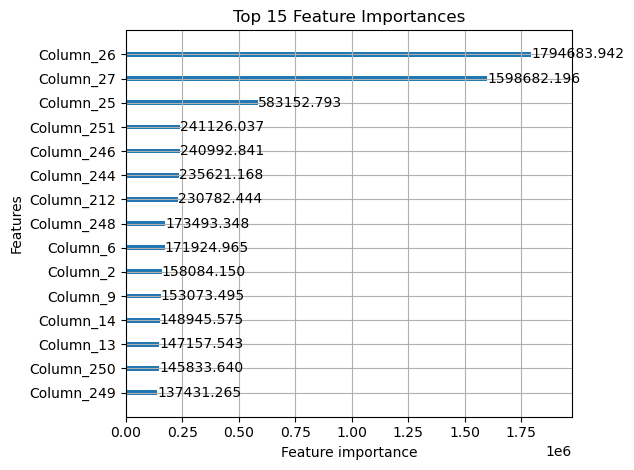

In [ ]:
y_pred_binary = (oof_preds > 0.5).astype(int)
print("AUC:", roc_auc_score(y, oof_preds))
print("F1:", f1_score(y, y_pred_binary))
print("Accuracy:", accuracy_score(y, y_pred_binary))

This bar chart shows the top 15 most important features used by the LightGBM model, based on their contribution to predictions. Features like Column_26 and Column_27 had the highest influence on model decisions. Understanding these helps us know which features the model relies on most for predicting loan defaults.

# 14. Submission

In [24]:
submission = pd.DataFrame({"SK_ID_CURR": application_test["SK_ID_CURR"], "TARGET": test_preds})
submission.to_csv("submission_lgbm_boosted_v3.csv", index=False)

# Key Findings:

1-The dataset contains many useful features, but also high missing values in some columns.

2-Feature engineering and aggregation from external files (e.g., bureau, credit card) significantly improved model performance.

3-The most important features came from derived ratios and historical credit behaviors.

# Lessons Learned:

1-Combining raw data with engineered features leads to better predictive power.

2-Handling missing values and irrelevant features is crucial for model stability.

3-LightGBM with proper tuning and feature selection can achieve strong AUC scores for imbalanced classification problems.

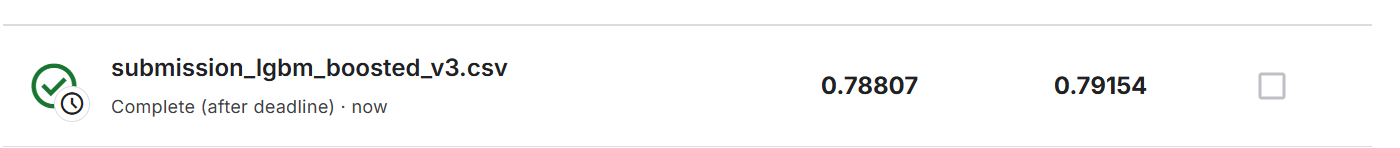

Omar bahaa eldin ahmed ali
222300410